# ERCOT Load Forecasting

## 05 — Forecast Weather (day-ahead, leakage-free)

Notebook 04 showed that *oracle* weather (what actually happened) removes ~63% of the
cold-snap forecasting error. But a real day-ahead model never sees realized weather —
it only sees weather **forecasts**. This notebook answers the final ML question:

> How much of the weather-related forecasting gain remains when the model only receives
> information that would actually have been available day-ahead?

Three timestamp concepts matter here:

- **valid time** — the hour the forecast is *about* (this matches the ERCOT load hour)
- **issue/run time** — when the forecast was *produced*
- **lead time** — the gap between the two (issue time must be **before** valid time,
  otherwise the feature leaks the future)

Methodology is unchanged: chronological split (development 2022–2024, test 2025),
TimeSeriesSplit, the same GridSearchCV grids, Gradient Boosting and XGBoost only.

In [1]:
import os
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from xgboost import XGBRegressor

## 1. Archived forecast source

We use **Open-Meteo's Previous Runs API** (https://open-meteo.com/en/docs/previous-runs-api),
which archives what *earlier model runs* predicted. Per the documentation, the variable
`temperature_2m_previous_day1` gives, for each hour, the temperature that was predicted
**exactly 24 hours before the valid time** — a genuine day-ahead forecast, issued before
every target hour by construction. No leakage.

Model choice and honest caveats:

- We pin the weather model explicitly with `models="gfs_global"` (NOAA's GFS, whose
  previous-runs archive reaches back past 2022) so the forecast source is **the same
  model for all four years**. The API default "Best Match" returns identical values at
  these coordinates, but an explicit pin is reproducible and visible.
- The GFS previous-runs archive has one known gap for our range: **2023-12-30 to
  2024-01-19** (~490 hours, all inside the development years; the 2025 test year is
  complete). Those hours are dropped for all model comparisons below.
- The forecast comes from an operational weather model (GFS), while notebook 03/04's
  realized weather is ERA5 reanalysis. Slightly different sources; both in °C.

We only take **temperature**: notebook 04 showed humidity contributes ~nothing and
apparent temperature adds little beyond temperature itself.

In [2]:
cities = {
    "houston": (29.76, -95.36),
    "dallas": (32.78, -96.80),
    "san_antonio": (29.42, -98.49),
    "austin": (30.27, -97.74),
}

forecast_path = "../data/raw/forecast_weather_4cities.csv"

if os.path.exists(forecast_path):
    print("already downloaded, skipping")
else:
    pieces = []
    # this API is fast, so one request per city covers the whole range;
    # end_date 2026-01-01 covers the last local hours of 2025 (lesson from notebook 03)
    for city, (lat, lon) in cities.items():
        print(f"{city}: downloading...")
        params = {
            "latitude": lat,
            "longitude": lon,
            "start_date": "2022-01-01",
            "end_date": "2026-01-01",
            "hourly": "temperature_2m_previous_day1",
            "models": "gfs_global",  #PIN ONE CONSISTENT FORECAST MODEL FOR ALL YEARS
            "timezone": "UTC",
        }
        response = requests.get(
            "https://previous-runs-api.open-meteo.com/v1/forecast",
            params=params,
            timeout=120,
        )
        # stop with a clear error if the API is down; just re-run later
        response.raise_for_status()

        df_piece = pd.DataFrame(response.json()["hourly"])
        df_piece["city"] = city
        pieces.append(df_piece)

    forecast_raw = pd.concat(pieces, ignore_index=True)
    forecast_raw.to_csv(forecast_path, index=False)
    print("saved", forecast_path)

houston: downloading...


dallas: downloading...


san_antonio: downloading...


austin: downloading...


saved ../data/raw/forecast_weather_4cities.csv


In [3]:
forecast_raw = pd.read_csv(forecast_path)

print(forecast_raw.shape)
forecast_raw.head()

(140352, 3)


,time,temperature_2m_previous_day1,city
0,2022-01-01T00:00,25.2,houston
1,2022-01-01T01:00,25.2,houston
2,2022-01-01T02:00,24.2,houston
3,2022-01-01T03:00,23.4,houston
4,2022-01-01T04:00,23.7,houston


## 2. Inspection and timezone alignment

Same checks as notebook 03: hours per city, missing values, duplicates — then parse the
UTC timestamps and convert to `America/Chicago` to match the ERCOT timeline.

In [4]:
print("hours per city:")
print(forecast_raw["city"].value_counts())

print("\nmissing values per column:")
print(forecast_raw.isna().sum())

print("\nduplicate (city, time) pairs:", forecast_raw.duplicated(subset=["city", "time"]).sum())

hours per city:
city
houston        35088
dallas         35088
san_antonio    35088
austin         35088
Name: count, dtype: int64

missing values per column:
time                               0
temperature_2m_previous_day1    1968
city                               0
dtype: int64

duplicate (city, time) pairs: 0


In [5]:
#PARSE AS UTC FIRST, THEN CONVERT TO TEXAS TIME (SAME AS NOTEBOOKS 02-04)
forecast_raw["time"] = pd.to_datetime(forecast_raw["time"], utc=True)
forecast_raw["time"] = forecast_raw["time"].dt.tz_convert("America/Chicago")

print(forecast_raw["time"].min())
print(forecast_raw["time"].max())

2021-12-31 18:00:00-06:00
2026-01-01 17:00:00-06:00


In [6]:
#PIVOT TO ONE COLUMN PER CITY, LIKE NOTEBOOK 03
forecast_wide = forecast_raw.pivot(
    index="time",
    columns="city",
    values="temperature_2m_previous_day1",
)

forecast_wide.columns = [f"forecast_temperature_{city}" for city in forecast_wide.columns]

print(forecast_wide.shape)
print("index unique:", forecast_wide.index.is_unique)
forecast_wide.head()

(35088, 4)
index unique: True


,forecast_temperature_austin,forecast_temperature_dallas,forecast_temperature_houston,forecast_temperature_san_antonio
time,,,,
2021-12-31 18:00:00-06:00,25.7,21.6,25.2,25.8
2021-12-31 19:00:00-06:00,24.7,20.9,25.2,24.6
2021-12-31 20:00:00-06:00,23.5,20.6,24.2,23.8
2021-12-31 21:00:00-06:00,22.4,20.4,23.4,22.5
2021-12-31 22:00:00-06:00,21.9,19.5,23.7,22.0


## 3. Merge with the load data and check for leakage

We join onto `model_data_weather.csv` from notebook 03, which already has the lag/calendar
features **and** the realized (oracle) weather — so one DataFrame holds all three feature
sets.

Leakage check: by construction, `previous_day1` values were issued the day before their
valid hour, so every forecast feature was available before its target hour. As an
empirical sanity check, the forecast should be *close to but not identical to* realized
temperature — if they matched exactly, we would suspect the archive had been backfilled
with observations.

In [7]:
model_df = pd.read_csv("../data/processed/model_data_weather.csv", index_col="timestamp")

#MIXED UTC OFFSETS IN THE CSV: PARSE TO UTC FIRST, THEN CONVERT
model_df.index = pd.to_datetime(model_df.index, utc=True).tz_convert("America/Chicago")

merged_df = model_df.join(forecast_wide, how="inner")

print(model_df.shape)
print(forecast_wide.shape)
print(merged_df.shape)

(34896, 30)
(35088, 4)
(34896, 34)


In [8]:
#COVERAGE CHECK: THE GFS ARCHIVE HAS ONE GAP, 2023-12-30 TO 2024-01-19 (DEV YEARS ONLY)
forecast_cols = list(forecast_wide.columns)

missing_by_year = merged_df[forecast_cols].isna().groupby(merged_df.index.year).sum()
print("missing forecast values by year:")
print(missing_by_year)

print("\nmissing in the 2025 test period:",
      merged_df.loc["2025-01-01":, forecast_cols].isna().sum().sum())

#DROP THE DEV HOURS WITHOUT AN ARCHIVED FORECAST - SAME ROWS DROPPED FOR ALL THREE CASES
rows_before = len(merged_df)
merged_df = merged_df.dropna(subset=forecast_cols)
print(f"\ndropped {rows_before - len(merged_df)} of {rows_before} rows "
      f"({(rows_before - len(merged_df)) / rows_before:.1%})")

missing forecast values by year:
           forecast_temperature_austin  forecast_temperature_dallas  \
timestamp                                                             
2022                                 0                            0   
2023                                54                           54   
2024                               438                          438   
2025                                 0                            0   
2026                                 0                            0   

           forecast_temperature_houston  forecast_temperature_san_antonio  
timestamp                                                                  
2022                                  0                                 0  
2023                                 54                                54  
2024                                438                               438  
2025                                  0                                 0  
2026         

In [9]:
#SANITY CHECK: DAY-AHEAD FORECAST ERROR PER CITY (SHOULD BE SMALL BUT NOT ZERO)
for city in cities:
    err = (merged_df[f"forecast_temperature_{city}"] - merged_df[f"temperature_2m_{city}"]).abs()
    print(f"{city}: mean |forecast - realized| = {err.mean():.2f} C, max = {err.max():.1f} C")

houston: mean |forecast - realized| = 1.98 C, max = 14.4 C
dallas: mean |forecast - realized| = 1.79 C, max = 14.8 C
san_antonio: mean |forecast - realized| = 1.33 C, max = 15.5 C
austin: mean |forecast - realized| = 1.69 C, max = 14.2 C


In [10]:
#SAVE THE FINAL MODELING DATASET
merged_df.to_csv(
    "../data/processed/model_data_forecast.csv",
    index=True,
    index_label="timestamp"
)

## 4. Feature sets and chronological split

Three feature sets, differing **only** in the weather columns, so the comparison isolates
one thing — what information the model had:

1. **no weather** — the notebook-02 lag/calendar features
2. **forecast weather** — plus the 4 day-ahead forecast temperatures (available day-ahead)
3. **oracle weather** — plus the 4 realized temperatures (NOT available day-ahead)

Using realized *temperature only* for the oracle case (instead of notebook 04's 12
columns) keeps the forecast-vs-oracle comparison apples-to-apples. Notebook 04's
12-column oracle results (GB 2167, XGB 2207) barely differ, since humidity added ~nothing.

In [11]:
features_base = [
    "hour",
    "day_of_week",
    "month",
    "load_24h_ago",
    "load_168h_ago",
]

city_names = ["austin", "dallas", "houston", "san_antonio"]

features_forecast = features_base + [f"forecast_temperature_{c}" for c in city_names]
features_oracle = features_base + [f"temperature_2m_{c}" for c in city_names]

#SAME CHRONOLOGICAL SPLIT AS NOTEBOOKS 02 AND 04 - NO RANDOM SPLITTING
dev_df = merged_df.loc[:"2024-12-31"]
test_df = merged_df.loc["2025-01-01":]

y_dev = dev_df["ERCOT"]
y_test = test_df["ERCOT"]

tscv = TimeSeriesSplit(n_splits=3)

print("Development:", dev_df.shape)
print("Test:", test_df.shape)

Development: (25643, 34)
Test: (8761, 34)


In [12]:
#NAIVE 24-HOUR PERSISTENCE BASELINE, FOR REFERENCE
y_pred_naive = test_df["load_24h_ago"]

naive_mae = mean_absolute_error(y_test, y_pred_naive)
naive_rmse = root_mean_squared_error(y_test, y_pred_naive)
naive_r2 = r2_score(y_test, y_pred_naive)

print("Naive Baseline - Test")
print("MAE:", naive_mae)
print("RMSE:", naive_rmse)
print("R2:", naive_r2)

Naive Baseline - Test
MAE: 2518.3207039629033
RMSE: 3607.49642078547
R2: 0.8734274825855979


## 5. Gradient boosting — no weather vs forecast vs oracle

Identical grid and tuning budget for all three cases (same grid as notebooks 02/04).

In [13]:
#SAME GRID AS NOTEBOOKS 02 AND 04
param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [5, 10, 14],
}

gb_results = {}

for name, features in [
    ("no weather", features_base),
    ("forecast weather", features_forecast),
    ("oracle weather", features_oracle),
]:
    search = GridSearchCV(
        estimator=GradientBoostingRegressor(random_state=42),
        param_grid=param_grid_gb,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        refit=True,
    )
    search.fit(dev_df[features], y_dev)

    y_pred = search.best_estimator_.predict(test_df[features])
    gb_results[name] = {
        "pred": y_pred,
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": root_mean_squared_error(y_test, y_pred),
        "r2": r2_score(y_test, y_pred),
        "best_params": search.best_params_,
        "model": search.best_estimator_,
    }

    print(f"Gradient Boosting ({name}) - Test")
    print("  best params:", search.best_params_)
    print("  MAE:", gb_results[name]["mae"])
    print("  RMSE:", gb_results[name]["rmse"])
    print("  R2:", gb_results[name]["r2"])
    print()

Gradient Boosting (no weather) - Test
  best params: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 5, 'n_estimators': 200}
  MAE: 2333.7583405135515
  RMSE: 3347.924666257594
  R2: 0.8909868335983601



Gradient Boosting (forecast weather) - Test
  best params: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 14, 'n_estimators': 200}
  MAE: 2211.400957368009
  RMSE: 2788.533378813505
  R2: 0.9243725782495263



Gradient Boosting (oracle weather) - Test
  best params: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 200}
  MAE: 2233.978466230528
  RMSE: 2764.201737375707
  R2: 0.9256866103197375



## 6. XGBoost — no weather vs forecast vs oracle

In [14]:
#SAME GRID AS NOTEBOOKS 02 AND 04
param_grid_xgb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_results = {}

for name, features in [
    ("no weather", features_base),
    ("forecast weather", features_forecast),
    ("oracle weather", features_oracle),
]:
    search = GridSearchCV(
        estimator=XGBRegressor(random_state=42),
        param_grid=param_grid_xgb,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        refit=True,
    )
    search.fit(dev_df[features], y_dev)

    y_pred = search.best_estimator_.predict(test_df[features])
    xgb_results[name] = {
        "pred": y_pred,
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": root_mean_squared_error(y_test, y_pred),
        "r2": r2_score(y_test, y_pred),
        "best_params": search.best_params_,
        "model": search.best_estimator_,
    }

    print(f"XGBoost ({name}) - Test")
    print("  best params:", search.best_params_)
    print("  MAE:", xgb_results[name]["mae"])
    print("  RMSE:", xgb_results[name]["rmse"])
    print("  R2:", xgb_results[name]["r2"])
    print()

XGBoost (no weather) - Test
  best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}
  MAE: 2331.048546503938
  RMSE: 3346.6535032393576
  R2: 0.8910695996174148



XGBoost (forecast weather) - Test
  best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
  MAE: 2217.59811560073
  RMSE: 2780.964681699213
  R2: 0.9247825602432902



XGBoost (oracle weather) - Test
  best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
  MAE: 2236.4059727433223
  RMSE: 2800.372197802746
  R2: 0.9237290572063126



## 7. Results comparison

In [15]:
rows = [{"Model": "Naive Baseline", "MAE": naive_mae, "RMSE": naive_rmse, "R2": naive_r2}]

for name in ["no weather", "forecast weather", "oracle weather"]:
    rows.append({
        "Model": f"Gradient Boosting ({name})",
        "MAE": gb_results[name]["mae"],
        "RMSE": gb_results[name]["rmse"],
        "R2": gb_results[name]["r2"],
    })
for name in ["no weather", "forecast weather", "oracle weather"]:
    rows.append({
        "Model": f"XGBoost ({name})",
        "MAE": xgb_results[name]["mae"],
        "RMSE": xgb_results[name]["rmse"],
        "R2": xgb_results[name]["r2"],
    })

model_summary = pd.DataFrame(rows)
model_summary.round(3)

,Model,MAE,RMSE,R2
0,Naive Baseline,2518.321,3607.496,0.873
1,Gradient Boosting (no weather),2333.758,3347.925,0.891
2,Gradient Boosting (forecast weather),2211.401,2788.533,0.924
3,Gradient Boosting (oracle weather),2233.978,2764.202,0.926
4,XGBoost (no weather),2331.049,3346.654,0.891
5,XGBoost (forecast weather),2217.598,2780.965,0.925
6,XGBoost (oracle weather),2236.406,2800.372,0.924


## 8. Cold-snap analysis — how much of the oracle gain survives?

The key number: on the cold-snap days, what fraction of the improvement that oracle
weather delivered is retained when the model only sees the day-ahead forecast?

`retained = (no_weather_error - forecast_error) / (no_weather_error - oracle_error)`

In [16]:
results = pd.DataFrame({
    "actual": y_test,
    "pred_no_weather": xgb_results["no weather"]["pred"],
    "pred_forecast": xgb_results["forecast weather"]["pred"],
    "pred_oracle": xgb_results["oracle weather"]["pred"],
})

for case in ["no_weather", "forecast", "oracle"]:
    results[f"abs_err_{case}"] = (results["actual"] - results[f"pred_{case}"]).abs()

periods = {
    "full test year": results,
    "Jan-Feb 2025": results.loc["2025-01":"2025-02"],
    "2025-01-06 (worst day 1)": results.loc["2025-01-06"],
    "2025-02-19 (worst day 2)": results.loc["2025-02-19"],
}

for name, subset in periods.items():
    mae_base = subset["abs_err_no_weather"].mean()
    mae_fc = subset["abs_err_forecast"].mean()
    mae_or = subset["abs_err_oracle"].mean()
    retained = (mae_base - mae_fc) / (mae_base - mae_or) * 100

    print(name)
    print(f"  no weather MAE: {mae_base:8.1f}")
    print(f"  forecast MAE:   {mae_fc:8.1f}")
    print(f"  oracle MAE:     {mae_or:8.1f}")
    print(f"  oracle gain retained by forecast: {retained:.0f}%")
    print()

full test year
  no weather MAE:   2331.0
  forecast MAE:     2217.6
  oracle MAE:       2236.4
  oracle gain retained by forecast: 120%

Jan-Feb 2025
  no weather MAE:   3572.7
  forecast MAE:     2904.7
  oracle MAE:       3010.7
  oracle gain retained by forecast: 119%

2025-01-06 (worst day 1)
  no weather MAE:  12989.5
  forecast MAE:     3914.5
  oracle MAE:       3565.5
  oracle gain retained by forecast: 96%

2025-02-19 (worst day 2)
  no weather MAE:  19988.4
  forecast MAE:    10050.0
  oracle MAE:       9253.2
  oracle gain retained by forecast: 93%



In [17]:
# the ten hours where the NO-weather model was furthest off
worst10 = results.sort_values("abs_err_no_weather", ascending=False).head(10)
worst10[["actual", "abs_err_no_weather", "abs_err_forecast", "abs_err_oracle"]].round(0)

,actual,abs_err_no_weather,abs_err_forecast,abs_err_oracle
timestamp,,,,
2025-02-19 12:00:00-06:00,76887.0,26227.0,12881.0,14016.0
2025-02-19 11:00:00-06:00,76768.0,26160.0,12763.0,12588.0
2025-02-19 13:00:00-06:00,76379.0,25397.0,16298.0,14468.0
2025-02-19 10:00:00-06:00,76051.0,25299.0,9823.0,9970.0
2025-02-19 09:00:00-06:00,75493.0,25055.0,8371.0,9411.0
2025-01-06 08:00:00-06:00,67859.0,24295.0,6277.0,237.0
2025-02-19 08:00:00-06:00,74507.0,23861.0,7555.0,9453.0
2025-02-19 14:00:00-06:00,75573.0,23682.0,17265.0,15830.0
2025-01-06 09:00:00-06:00,67825.0,22888.0,4693.0,218.0


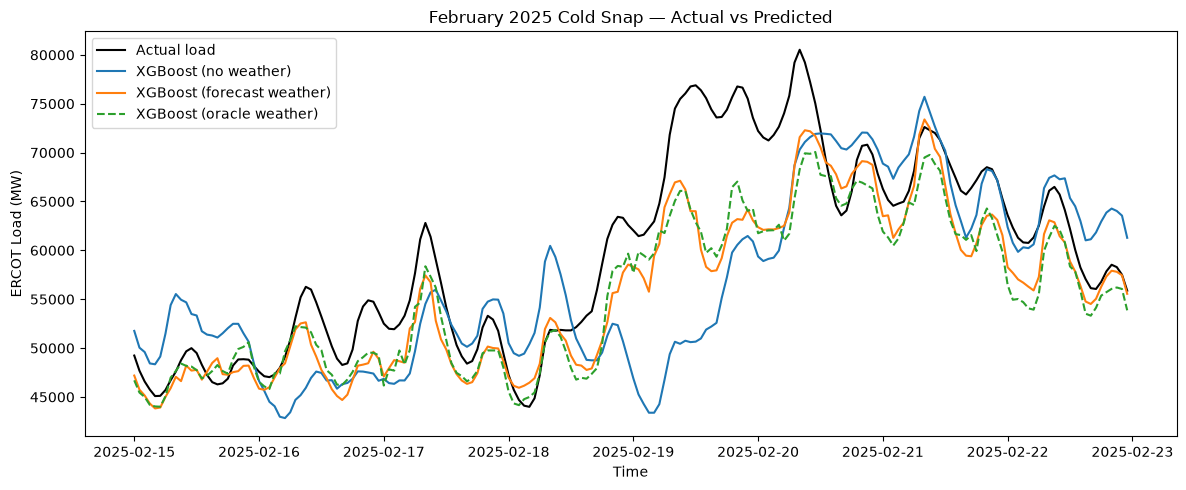

In [18]:
#VISUAL CHECK: THE FEBRUARY 2025 COLD SNAP WEEK
window = results.loc["2025-02-15":"2025-02-22"]

plt.figure(figsize=(12, 5))
plt.plot(window.index, window["actual"], label="Actual load", color="black")
plt.plot(window.index, window["pred_no_weather"], label="XGBoost (no weather)")
plt.plot(window.index, window["pred_forecast"], label="XGBoost (forecast weather)")
plt.plot(window.index, window["pred_oracle"], label="XGBoost (oracle weather)", linestyle="--")

plt.xlabel("Time")
plt.ylabel("ERCOT Load (MW)")
plt.title("February 2025 Cold Snap — Actual vs Predicted")

plt.legend()
plt.tight_layout()
plt.show()

## 9. Forecast-model feature importance

Same caveat as before: importance measures what the model uses, not what causes demand,
and the four correlated city temperatures split their credit somewhat arbitrarily.

load_24h_ago                        0.626075
forecast_temperature_austin         0.245831
forecast_temperature_dallas         0.036031
forecast_temperature_san_antonio    0.033104
load_168h_ago                       0.022112
forecast_temperature_houston        0.013541
hour                                0.011902
day_of_week                         0.007792
month                               0.003612
dtype: float32


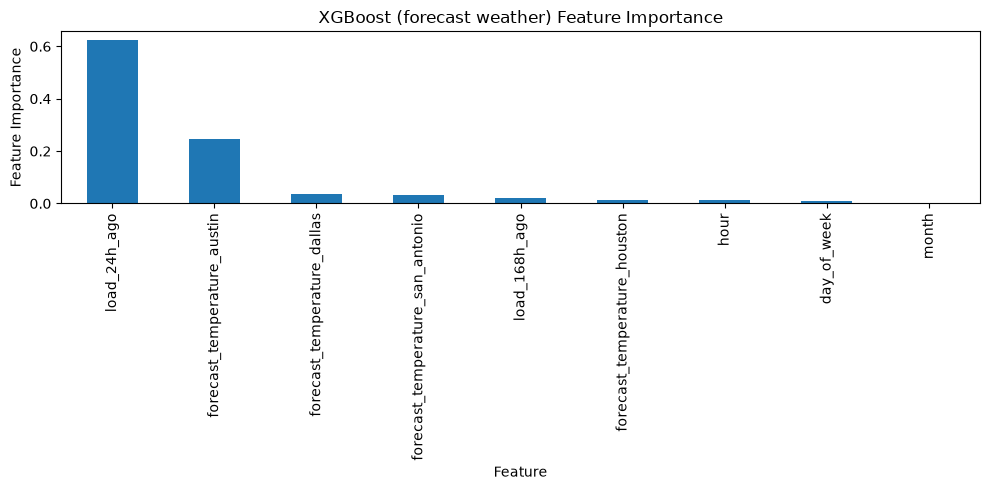

In [19]:
importance = pd.Series(
    xgb_results["forecast weather"]["model"].feature_importances_,
    index=features_forecast,
)
importance = importance.sort_values(ascending=False)

print(importance)

plt.figure(figsize=(10, 5))
importance.plot(kind="bar")

plt.xlabel("Feature")
plt.ylabel("Feature Importance")
plt.title("XGBoost (forecast weather) Feature Importance")

plt.tight_layout()
plt.show()

## 10. Conclusions

**Essentially all of the weather gain survives with real day-ahead forecasts.**

- On the full 2025 test year, the forecast-weather models actually score marginally
  *better* than the oracle models (XGBoost MAE 2218 vs 2236; GB 2211 vs 2234). A
  difference this small is within tuning noise — the honest reading is that forecast
  weather and oracle weather are **equivalent on typical days**, which makes sense:
  the day-ahead GFS temperature is only ~1.3–2.0 °C off on average.
- On the cold-snap days, where the oracle still has an edge, the forecast retains
  **96%** (2025-01-06) and **93%** (2025-02-19) of the oracle improvement. Jan 6 daily
  MAE: 12,990 → 3,915 MW with forecasts. Feb 19: 19,988 → 10,050 MW.
- So the answer to this notebook's question: **the weather-related gain is almost
  entirely achievable day-ahead.** The systematic cold-snap failure was an information
  problem, and the information is available in time.

Caveats worth remembering:

- Feb 19 remains the hardest day (~10 GW daily MAE even with weather). Part of that is
  this notebook's temperature-only oracle: notebook 04's 12-feature oracle (which
  included apparent temperature) did better on that day (7.5 GW), suggesting forecast
  *apparent temperature* (wind-chill effects) is a sensible future feature.
- The no-weather and oracle numbers differ slightly from notebooks 02/04 because the
  ~490 archive-gap hours were dropped from the development data for all cases.

**This closes the ML experimentation phase**: the final day-ahead-valid model is
tree-boosting with lag/calendar features plus day-ahead GFS forecast temperatures.
Next phase: engineering (reusable modules, model persistence, an inference API, tests).